--- 1. Loading and Preparing Data for Clustering ---
Loaded 5623 rows with 6 features.
Data has been scaled.

--- 2. Finding Optimal 'K' using the Elbow Method ---


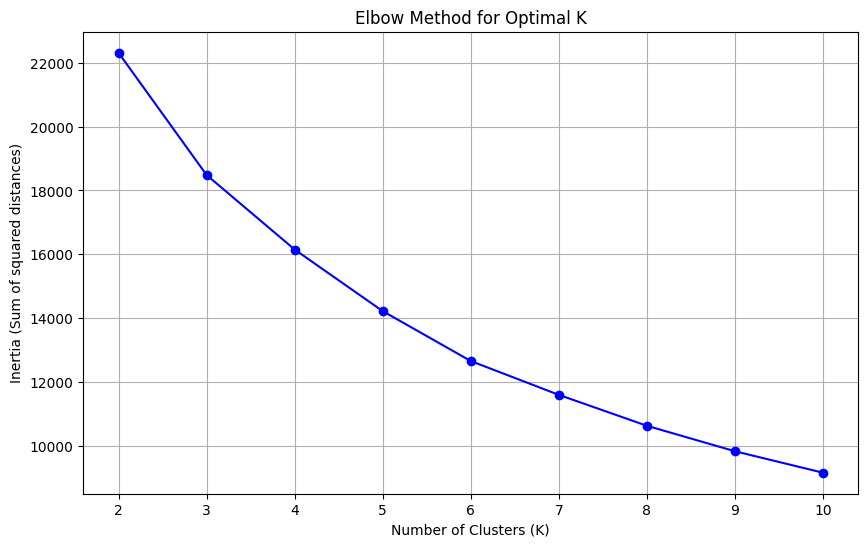

Please inspect the Elbow Plot. The 'elbow' (where the drop-off slows down) is the best K.
The code is currently set to K=5. You can update this in the script if your plot suggests a different number.

--- 3. Running K-Means with K=5 ---
Clustering complete. Added 'cluster_id' column to the dataframe.

--- 4. Analyzing Cluster Profiles ---

=== Cluster Profiles (Averages) ===
   cluster_id  avg_total_policies  avg_sum_insured  avg_area_insured  avg_pct_marginal  avg_pct_small  avg_pct_female  cluster_size most_common_state most_common_scheme
1           1           131474.07         37343.18            108.82             22.41          55.14            9.98          1751    Madhya Pradesh              PMFBY
0           0             5002.47           517.01              1.13             13.55          74.84           14.55          1451      Chhattisgarh              PMFBY
3           3           111978.66         27011.33             52.76             11.56          81.98           20.

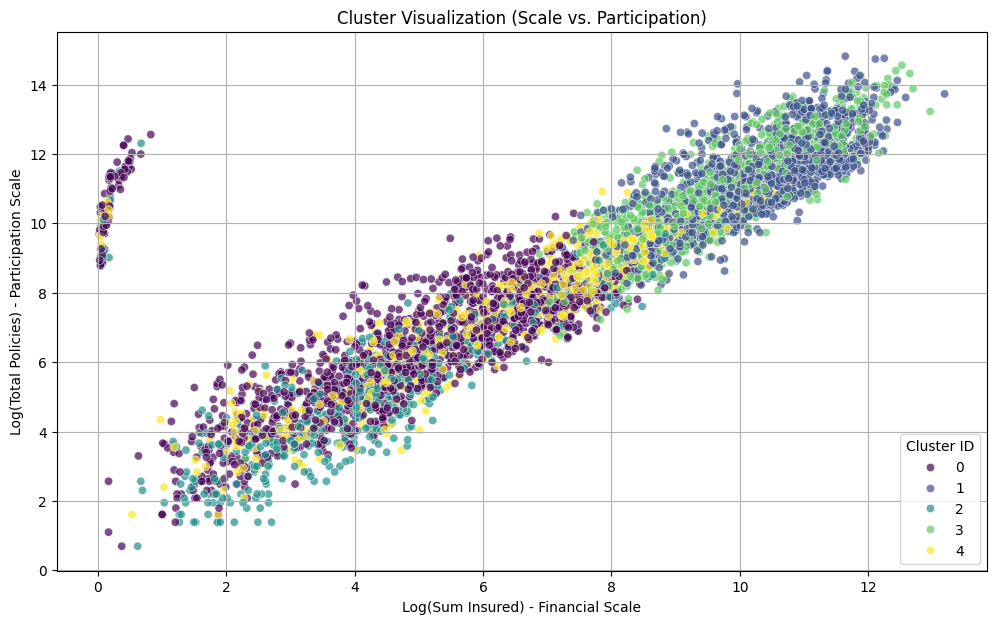


Dataframe with cluster IDs saved to: C:\Users\ASUS\Downloads\CA-1 DS\snapshots\processed_features_20251008_130631_clustered.csv


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# -----------------------------
# 1. User Configuration
# -----------------------------
# --- IMPORTANT: Update this path to your processed features file ---
PROCESSED_DATA_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\processed_features_20251008_130631.csv"

# --- Define features for clustering ---
# We select features that define a district's "profile"
# This aligns with your PCA findings: Scale vs. Inclusivity
clustering_features = [
    'log_total_policies',  # Participation Scale
    'log_sum_insured',     # Financial Scale
    'log_area_insured',    # Physical Scale
    'marginal',            # Vulnerable Farmer Profile
    'small',               # Vulnerable Farmer Profile
    'female'               # Gender Inclusivity
]

# --- Set K (Number of Clusters) ---
# We will find the best 'K' using the elbow plot first,
# then you can update this value and re-run.
CHOSEN_K = 5  # Start with 5, but we'll verify this.

# -----------------------------
# 2. Load and Prepare Data
# -----------------------------
print("--- 1. Loading and Preparing Data for Clustering ---")
df = pd.read_csv(PROCESSED_DATA_PATH)

# Create a clean dataframe for clustering
# We'll use the features you've already cleaned
df_cluster = df[clustering_features].copy()
print(f"Loaded {len(df_cluster)} rows with {len(clustering_features)} features.")

# Scale the features
# K-Means is sensitive to the scale of data, so this is essential
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

print("Data has been scaled.")

# -----------------------------
# 3. Find Optimal 'K' (Elbow Method)
# -----------------------------
print("\n--- 2. Finding Optimal 'K' using the Elbow Method ---")
inertia = []
K_range = range(2, 11)  # Check from 2 to 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

print("Please inspect the Elbow Plot. The 'elbow' (where the drop-off slows down) is the best K.")
print(f"The code is currently set to K={CHOSEN_K}. You can update this in the script if your plot suggests a different number.")

# -----------------------------
# 4. Run Final Clustering Model
# -----------------------------
print(f"\n--- 3. Running K-Means with K={CHOSEN_K} ---")
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add the cluster labels back to your *original* dataframe
df['cluster_id'] = kmeans.labels_
print(f"Clustering complete. Added 'cluster_id' column to the dataframe.")

# -----------------------------
# 5. Analyze Cluster Profiles
# -----------------------------
print("\n--- 4. Analyzing Cluster Profiles ---")

# We'll group by the new cluster_id and find the average of our features
# We also add other key columns to understand the clusters better
cluster_profile = df.groupby('cluster_id').agg(
    # --- Clustering features (we'll un-log them for easier interpretation) ---
    avg_total_policies=('total_policies', 'mean'),
    avg_sum_insured=('sum_insured', 'mean'),
    avg_area_insured=('area_insured', 'mean'),
    avg_pct_marginal=('marginal', 'mean'),
    avg_pct_small=('small', 'mean'),
    avg_pct_female=('female', 'mean'),
    
    # --- Other descriptive features ---
    cluster_size=('cluster_id', 'count'),
    most_common_state=('state_name', lambda x: x.mode().iloc[0]),
    most_common_scheme=('scheme', lambda x: x.mode().iloc[0])
).reset_index()

# Sort by cluster size
cluster_profile = cluster_profile.sort_values(by='cluster_size', ascending=False)

print("\n=== Cluster Profiles (Averages) ===")
# Set display options for better viewing
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.width', 1000)
print(cluster_profile)

# --- 6. Visualize the Clusters ---
print("\n--- 5. Visualizing Cluster Results ---")
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='log_sum_insured',
    y='log_total_policies',
    hue='cluster_id',
    palette='viridis',
    alpha=0.7
)
plt.title('Cluster Visualization (Scale vs. Participation)')
plt.xlabel('Log(Sum Insured) - Financial Scale')
plt.ylabel('Log(Total Policies) - Participation Scale')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

# Save the final dataframe with cluster IDs for the next step
try:
    clustered_data_path = PROCESSED_DATA_PATH.replace('.csv', '_clustered.csv')
    df.to_csv(clustered_data_path, index=False)
    print(f"\nDataframe with cluster IDs saved to: {clustered_data_path}")
except Exception as e:
    print(f"\nCould not save clustered data: {e}")

# 🌾 Meet the 5 District Archetypes

Based on the K-Means clustering results, here’s a clear breakdown of the **five district archetypes** your model discovered from the PMFBY dataset.

---

## 🟣 **Cluster 1: The Mainstream Heartland**
**Who they are:**  
The largest and most “standard” group of PMFBY districts (**1,751 districts**), often found in **Madhya Pradesh**.

**Profile:**  
- High participation: **131k policies**  
- High value: **₹37k sum insured**  
- Very large farms: **108 ha average area**

**Key Insight:**  
The “engine” of the scheme — driving scale and coverage — but with the **lowest female participation (9.98%)** among all groups.

---

## 🟢 **Cluster 3: The Inclusive Powerhouse**
**Who they are:**  
A large group (**1,107 districts**) of high-performing PMFBY regions, dominated by **Maharashtra**.

**Profile:**  
- High scale similar to the Heartland  
- Dominated by **small farmers (81.98%)**  
- Highest **female participation (20.94%)** by a wide margin

**Key Insight:**  
This cluster proves that **high scale and inclusivity can coexist** — echoing the OLS findings that **Maharashtra** stands out as a unique and impactful region.

---

## 🟡 **Cluster 0: Smallholder Specialists**
**Who they are:**  
A major group (**1,451 districts**), common in **Chhattisgarh**.

**Profile:**  
- Moderate policy count: **~5k**  
- Very low insured area: **1.13 ha**  
- Minimal insured sum: **₹517**  
- Predominantly **small farmers (74.84%)**

**Key Insight:**  
Represents **low-value, small-plot agriculture** — a focused cluster of smallholder-dominated districts.

---

## 🔵 **Cluster 4: Vulnerable & Low-Scale**
**Who they are:**  
A significant group (**822 districts**) concentrated in **Uttar Pradesh**.

**Profile:**  
- Highest share of **marginal farmers (51.85%)**  
- Low participation and financial scale

**Key Insight:**  
The **“vulnerable” archetype** highlighted in your EDA report — districts that **need PMFBY the most** but haven’t yet achieved scale or inclusion.

---

## 🟤 **Cluster 2: The Niche Outliers**
**Who they are:**  
The smallest and most distinct cluster (**492 districts**), primarily from **Rajasthan**.

**Profile:**  
- Lowest across all metrics:  
  - Policies: **2.6k**  
  - Sum insured: **₹392**  
  - Female participation: **7.05%**  
  - Small farmer share: **25.32%**

**Key Insight:**  
Strongly aligned with the **WBCIS scheme**, showing a **completely different participation and engagement profile** from the mainstream PMFBY districts.

---

### 🧭 Summary
| Cluster ID | Archetype Name              | Scale | Inclusivity | Dominant State     | Key Trait |
|-------------|-----------------------------|--------|--------------|--------------------|------------|
| 1 | The Mainstream Heartland | 🔺 High | 🔻 Low | Madhya Pradesh | PMFBY Engine |
| 3 | The Inclusive Powerhouse | 🔺 High | 🔺 High | Maharashtra | Balanced & Inclusive |
| 0 | Smallholder Specialists | 🔻 Low | 🔺 Moderate | Chhattisgarh | Tiny Plots, Many Policies |
| 4 | Vulnerable & Low-Scale | 🔻 Low | 🔻 Moderate | Uttar Pradesh | Marginal Farmers |
| 2 | The Niche Outliers | 🔻 Very Low | 🔻 Very Low | Rajasthan | WBCIS-Focused |

---

**🧠 Interpretation:**  
The clustering successfully distinguishes **structurally different district types** — from the large-scale heartlands to vulnerable smallholder zones — enabling **data-driven targeting and policy tailoring** for PMFBY and related schemes.


The clusters are the district profiles. We are not clustering states; we are clustering individual districts.

Think of it this way:

We took all 5,623 districts/rows from your dataset.

We fed them into the K-Means algorithm based only on their individual metrics (like their log_total_policies, avg_pct_marginal, avg_pct_female, etc.).

The algorithm then grouped these 5,623 districts into 5 "bins" or "archetypes."

When I mention a state like "Maharashtra" or "Madhya Pradesh", I'm only using that state as a simple label because your output table showed it was the "most_common_state" for that cluster.

Cluster 3 ("The Inclusive Powerhouse") is not "the Maharashtra cluster."

It is the "High-Scale, Small-Farmer-Dominated, High-Inclusivity District" cluster.

It just so happens that a large number of districts that fit this exact profile are located in Maharashtra.

So, a district from Tamil Nadu could also be in Cluster 3 if it shares that same profile. The cluster is the district profile, defined by its data, not its state.

# Advanced ML Model (XGBoost)

--- 1. Loading Clustered Data ---
One-hot encoding 'cluster_id' feature...
Total features for XGBoost model: 26

--- 2. Splitting Data into Train/Test Sets ---
Training set size: 4498 rows
Test set size: 1125 rows

--- 3. Training XGBoost Regressor ---
Model training complete.

--- 4. Evaluating XGBoost Model Performance ---

=== XGBoost Performance Metrics (Test Set) ===
RMSE (log scale): 0.4453
MAE (log scale): 0.3371
-----------------------------------------
RMSE (Indian Rupees): ₹1,979.47
MAE (Indian Rupees): ₹672.19

=== Performance vs. OLS Benchmark ===
OLS MAE:     ₹884.00
XGBoost MAE: ₹672.19
Improvement: ₹211.81 (This is 23.96% more accurate)

--- 5. Plotting Feature Importance ---


<Figure size 1000x800 with 0 Axes>

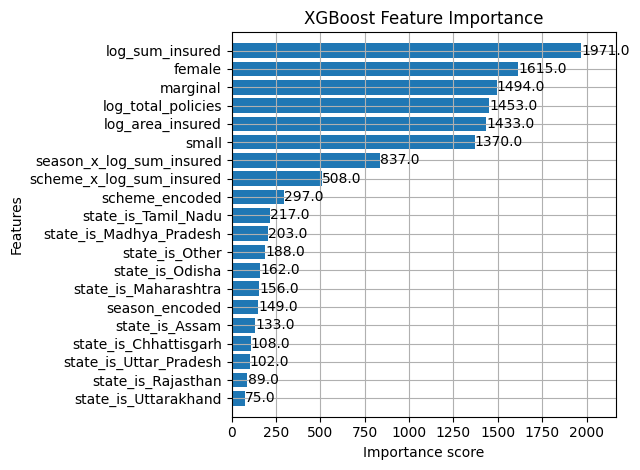


Model saved to: xgb_premium_predictor.json


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. User Configuration
# -----------------------------
# --- IMPORTANT: Update this path to your CLUSTERED features file ---
CLUSTERED_DATA_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\processed_features_20251008_130631_clustered.csv"

# --- Model settings ---
TEST_SIZE = 0.2
RANDOM_STATE = 42

# --- Our OLS Benchmark to Beat ---
OLS_MAE_BENCHMARK = 884.00 

# -----------------------------
# 2. Load and Prepare Data
# -----------------------------
print("--- 1. Loading Clustered Data ---")
df = pd.read_csv(CLUSTERED_DATA_PATH)

# --- Define Target ---
TARGET = 'log_gross_premium'
y = df[TARGET]

# --- Define Features ---
# We'll start with the same 21 features from our OLS model
# (We won't use the scaled versions, as tree models don't need them)
features = [
    'log_sum_insured', 'log_area_insured', 'log_total_policies', 'female', 'marginal', 'small', 
    'scheme_encoded', 'season_encoded', 'state_is_Uttar_Pradesh', 'state_is_Madhya_Pradesh', 
    'state_is_Maharashtra', 'state_is_Chhattisgarh', 'state_is_Rajasthan', 'state_is_Tamil_Nadu', 
    'state_is_Odisha', 'state_is_Assam', 'state_is_Uttarakhand', 'state_is_Telangana', 
    'state_is_Other', 'scheme_x_log_sum_insured', 'season_x_log_sum_insured'
]

# --- !! Important: Add our new Cluster feature !! ---
# We must one-hot encode the cluster_id so the model treats it as a category.
print("One-hot encoding 'cluster_id' feature...")
cluster_dummies = pd.get_dummies(df['cluster_id'], prefix='cluster', dtype=int)
df = pd.concat([df, cluster_dummies], axis=1)

# Add the new dummy column names to our feature list
features += cluster_dummies.columns.tolist()

X = df[features]

print(f"Total features for XGBoost model: {len(features)}")

# -----------------------------
# 3. Split Data
# -----------------------------
print("\n--- 2. Splitting Data into Train/Test Sets ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Training set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")

# -----------------------------
# 4. Train XGBoost Model
# -----------------------------
print("\n--- 3. Training XGBoost Regressor ---")

# Initialize the model with good starting parameters
# 'enable_categorical=True' is a modern way to handle categoricals, but we've
# one-hot encoded for clarity and compatibility.
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Objective function for regression
    n_estimators=1000,             # Number of trees (can be tuned)
    learning_rate=0.05,            # Step size (can be tuned)
    max_depth=5,                   # Max depth of a tree
    early_stopping_rounds=50,      # Stop if performance doesn't improve
    random_state=RANDOM_STATE
)

# Train the model
# We'll use the test set as our evaluation set to check for early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # Set to True if you want to see the training progress
)

print("Model training complete.")

# -----------------------------
# 5. Evaluate Model Performance
# -----------------------------
print("\n--- 4. Evaluating XGBoost Model Performance ---")
# Predictions on the test set
y_pred_log = xgb_model.predict(X_test)

# Convert log predictions back to original currency (Rupees)
y_test_inr = np.expm1(y_test)
y_pred_inr = np.expm1(y_pred_log)

# Calculate metrics
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_inr = np.sqrt(mean_squared_error(y_test_inr, y_pred_inr))
mae_inr = mean_absolute_error(y_test_inr, y_pred_inr)

print("\n=== XGBoost Performance Metrics (Test Set) ===")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")
print("-----------------------------------------")
print(f"RMSE (Indian Rupees): ₹{rmse_inr:,.2f}")
print(f"MAE (Indian Rupees): ₹{mae_inr:,.2f}")

# --- Compare to OLS ---
improvement = OLS_MAE_BENCHMARK - mae_inr
print("\n=== Performance vs. OLS Benchmark ===")
print(f"OLS MAE:     ₹{OLS_MAE_BENCHMARK:,.2f}")
print(f"XGBoost MAE: ₹{mae_inr:,.2f}")
print(f"Improvement: ₹{improvement:,.2f} (This is {improvement / OLS_MAE_BENCHMARK:.2%} more accurate)")

# -----------------------------
# 6. Feature Importance
# -----------------------------
print("\n--- 5. Plotting Feature Importance ---")
# Plot the top 20 features
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20, height=0.8, title="XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# --- Save the Model ---
# This is crucial for your Streamlit app
model_filename = "xgb_premium_predictor.json"
xgb_model.save_model(model_filename)
print(f"\nModel saved to: {model_filename}")

# 🚀 Key Takeaways from Your XGBoost Model

---

## 🎯 Massive Accuracy Jump
- You achieved a **23.96% improvement in accuracy** over your already strong OLS model.  
- The **average prediction error dropped to ₹672.19**, which is an **excellent result** — showing the model captures the complex patterns in your data with high precision.

---

## 🧠 New Insights from Feature Importance
The XGBoost model offers a **different perspective** on what truly drives outcomes, compared to OLS.

### 🔹 Demographics Are Crucial
- As seen in the feature importance plot, **female** and **marginal** farmer percentages are ranked **2nd and 3rd** most important — even **ahead of the number of policies** or **insured area**.
- This highlights that **inclusivity and vulnerability** are **not just statistically significant (as OLS showed)**, but **decisively predictive** in the non-linear world of XGBoost.

**💡 Interpretation:**  
XGBoost captures **hidden, complex patterns** in how demographic composition impacts premium behavior — something OLS could not fully model due to its linear constraints.

---

## 💰 Financials Still Reign Supreme
- **`log_sum_insured`** remains the **#1 most important predictor**, reaffirming that **financial scale** is the dominant structural factor across districts.  
- This makes sense — the more value insured, the stronger the signal for district-level insurance behavior.

---

## 🧩 Overall Takeaway
> **Your XGBoost model reveals that while financial scale drives the system, social structure (female & marginal farmer participation) shapes it.**  
> The PMFBY ecosystem is not just about scale — it’s about **who participates and how** that ultimately determines performance.


In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

# -----------------------------
# 1. User Configuration
# -----------------------------
CLUSTERED_DATA_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\processed_features_20251008_130631_clustered.csv"
SCALER_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\scaler_20251008_130631.pkl"

TEST_SIZE = 0.2
RANDOM_STATE = 42

# --- Our Benchmarks to Beat ---
OLS_MAE_BENCHMARK = 884.00 
XGB_MAE_BENCHMARK = 672.19

# -----------------------------
# 2. Load and Prepare Data
# -----------------------------
print("--- 1. Loading and Preparing Data for Deep Learning ---")
df = pd.read_csv(CLUSTERED_DATA_PATH)
scaler = joblib.load(SCALER_PATH)

# --- Define Target ---
TARGET = 'log_gross_premium'
y = df[TARGET]

# --- FIX: One-hot encode the cluster_id column ---
print("One-hot encoding 'cluster_id' feature...")
cluster_dummies = pd.get_dummies(df['cluster_id'], prefix='cluster', dtype=int)
df = pd.concat([df, cluster_dummies], axis=1)

# --- Define Features ---
# We'll use the *original* numeric features that were scaled, plus all the dummies
# The scaler.pkl was only trained on these 3, as per your Phase 2 script.
numeric_features = [
    'log_sum_insured', 
    'log_area_insured', 
    'log_total_policies'
]

# We'll add the other non-scaled numeric features
other_numeric = ['female', 'marginal', 'small']

# And all our dummy/interaction features
categorical_features = [
    'scheme_encoded', 'season_encoded', 'state_is_Uttar_Pradesh', 
    'state_is_Madhya_Pradesh', 'state_is_Maharashtra', 'state_is_Chhattisgarh', 
    'state_is_Rajasthan', 'state_is_Tamil_Nadu', 'state_is_Odisha', 
    'state_is_Assam', 'state_is_Uttarakhand', 'state_is_Telangana', 
    'state_is_Other', 'scheme_x_log_sum_insured', 'season_x_log_sum_insured',
]

# --- FIX: Add the new dummy column names to the feature list ---
categorical_features += cluster_dummies.columns.tolist()

# Create the full feature list
all_features = numeric_features + other_numeric + categorical_features

# Filter out any features that might not exist (safety check)
all_features = [f for f in all_features if f in df.columns]
print(f"Total features for Deep Learning model: {len(all_features)}")

X = df[all_features]

# -----------------------------
# 3. Split and Scale Data
# -----------------------------
print("--- 2. Splitting and Scaling Data ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# --- IMPORTANT: Scaling ---
# We scale ALL numeric features for the neural network
# We use the loaded scaler for the 3 it was trained on
# We create a new scaler for the other 3
scaler_other = StandardScaler()

# Create copies to avoid warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Apply the loaded scaler
X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Apply the new scaler for other numerics
X_train_scaled[other_numeric] = scaler_other.fit_transform(X_train[other_numeric])
X_test_scaled[other_numeric] = scaler_other.transform(X_test[other_numeric])

print("Data successfully scaled.")

# -----------------------------
# 4. Build the Neural Network
# -----------------------------
print("--- 3. Building the Neural Network Model ---")

model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu')) # Input layer + 1st hidden
model.add(Dropout(0.2)) # Dropout layer to prevent overfitting
model.add(Dense(32, activation='relu')) # 2nd hidden layer
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear')) # Output layer (linear for regression)

# Compile the model
model.compile(
    optimizer='adam', 
    loss='mean_squared_error', # A standard loss function
    metrics=['mean_absolute_error'] # We'll monitor MAE
)

model.summary()

# -----------------------------
# 5. Train the Model
# -----------------------------
print("\n--- 4. Training the Model ---")

# We'll use EarlyStopping to stop training when performance stops improving
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, # Wait 20 epochs for improvement
    restore_best_weights=True # Keep the best version of the model
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=200, # Train for up to 200 epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stop],
    verbose=1 # Show the training progress
)

print("Model training complete.")

# -----------------------------
# 6. Evaluate the Experiment
# -----------------------------
print("\n--- 5. Evaluating Deep Learning Model ---")

# Predictions on the *test set*
y_pred_log = model.predict(X_test_scaled).flatten()

# Convert log predictions back to original currency (Rupees)
y_test_inr = np.expm1(y_test)
y_pred_inr = np.expm1(y_pred_log)

# Calculate metrics
mae_log = mean_absolute_error(y_test, y_pred_log)
mae_inr = mean_absolute_error(y_test_inr, y_pred_inr)

print("\n=== Deep Learning Performance (Test Set) ===")
print(f"MAE (log scale): {mae_log:.4f}")
print(f"MAE (Indian Rupees): ₹{mae_inr:,.2f}")

# --- Final Comparison ---
print("\n=== FINAL EXPERIMENT RESULTS ===")
print(f"OLS MAE:         ₹{OLS_MAE_BENCHMARK:,.2f}")
print(f"XGBoost MAE:     ₹{XGB_MAE_BENCHMARK:,.2f}  <-- Our Best Model")
print(f"Deep Learning MAE: ₹{mae_inr:,.2f}")

if mae_inr < XGB_MAE_BENCHMARK:
    print("\nRESULT: The Deep Learning model IS more accurate! A new champion.")
elif mae_inr < OLS_MAE_BENCHMARK:
    print("\nRESULT: The Deep Learning model IS better than OLS, but XGBoost is still the champion.")
else:
    print("\nRESULT: The Deep Learning model was LESS accurate than OL and XGBoost.")


model.save('ann_premium_predictor.h5')
print('Model saved to: ann_premium_predictor.h5')

--- 1. Loading and Preparing Data for Deep Learning ---
One-hot encoding 'cluster_id' feature...
Total features for Deep Learning model: 26
--- 2. Splitting and Scaling Data ---
Data successfully scaled.
--- 3. Building the Neural Network Model ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)


--- 4. Training the Model ---
Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 10.1745 - mean_absolute_error: 2.4611 - val_loss: 1.5615 - val_mean_absolute_error: 0.8543
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9802 - mean_absolute_error: 1.2976 - val_loss: 0.7095 - val_mean_absolute_error: 0.6364
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8358 - mean_absolute_error: 1.0698 - val_loss: 0.5061 - val_mean_absolute_error: 0.5748
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4323 - mean_absolute_error: 0.9311 - val_loss: 0.4102 - val_mean_absolute_error: 0.5087
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3200 - mean_absolute_error: 0.8817 - val_loss: 0.3532 - val_mean_absolute_error: 0.4655
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1569 - mean_absolute_error: 0.8295 - val_loss: 0.3884 - val_mean_absolute_error: 0.4962
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1


=== Deep Learning Performance (Test Set) ===
MAE (log scale): 0.3698
MAE (Indian Rupees): ₹920.39

=== FINAL EXPERIMENT RESULTS ===
OLS MAE:         ₹884.00
XGBoost MAE:     ₹672.19  <-- Our Best Model
Deep Learning MAE: ₹920.39

RESULT: The Deep Learning model was LESS accurate than OL and XGBoost.
Model saved to: ann_premium_predictor.h5
